# Titanic Survival Predicton

The objective is to predict if passanger has survived or not.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

%matplotlib inline

In [2]:
train=pd.read_csv("train.csv")
test=pd.read_csv("test.csv")

print("Train dataset has {} samples and {} attributes".format(*train.shape))
print("Test dataset has {} samples and {} attributes".format(*test.shape))

Train dataset has 891 samples and 12 attributes
Test dataset has 418 samples and 11 attributes


In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


We have 11 feature columns and target variable **Survived** which is binary.

Pclass, Sex and Embarked are **Categorical** Features while Age, SibSp, Parch and Fare are **continuous** variables.

We will use Name, Ticket and Cabin variable in Feature Engineering

## EDA

In [ ]:
fig , ax = plt.subplots(figsize=(6,4))
sns.countplot(x='Survived', data=train)
plt.title("Count of Survival")
plt.show()

In [ ]:
n=len(train)
surv_0=len(train[train['Survived']==0])
surv_1=len(train[train['Survived']==1])

print("% of passanger survived in train dataset: ",surv_1*100/n)
print("% of passanger not survived in train dataset: ",surv_0*100/n)

Passanger not survived has edge over survived passanger.  

And even if we do nothing we would get approximately 61% accuracy by simple marking all passangers as not survived(**Accuracy Paradox**). So our aim should be to get accuracy higher than this.

### Let's find correlation between Numeric Variable

In [4]:
cat=['Pclass','Sex','Embarked']
num=['Age','SibSp','Parch','Fare']

In [5]:
train.select_dtypes(exclude='object')

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000
887,888,1,1,19.0,0,0,30.0000
888,889,0,3,NaN,1,2,23.4500
889,890,1,1,26.0,0,0,30.0000


In [6]:
corr_df=train[num]  
#New dataframe to calculate correlation between numeric features
cor= corr_df.corr(method='pearson')
print(cor)

            Age     SibSp     Parch      Fare
Age    1.000000 -0.308247 -0.189119  0.096067
SibSp -0.308247  1.000000  0.414838  0.159651
Parch -0.189119  0.414838  1.000000  0.216225
Fare   0.096067  0.159651  0.216225  1.000000


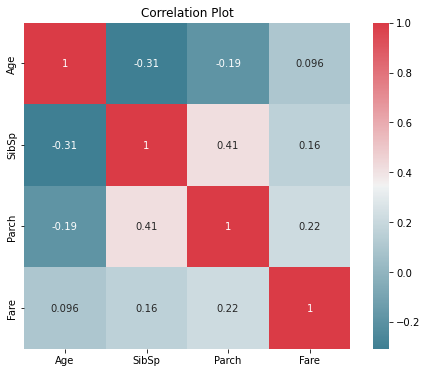

In [7]:
fig, ax =plt.subplots(figsize=(8, 6))
plt.title("Correlation Plot")
sns.heatmap(cor, mask=np.zeros_like(cor, dtype=bool), cmap=sns.diverging_palette(220, 10, as_cmap=True),
            square=True, ax=ax,annot=True)
plt.show()

There's no strong correlation between any two variables. The strongest correlation is between **SibSp** and **Parch** features (0.414).

 I would like to keep all the features as there is no strong evidence of data redundancy.

### Let's use chi-square test to understand relationship between categorical variables and target variable

In [ ]:
csq=chi2_contingency(pd.crosstab(train['Survived'], train['Sex']))
print("P-value: ",csq[1])

In [ ]:
csq2=chi2_contingency(pd.crosstab(train['Survived'], train['Embarked']))
print("P-value: ",csq2[1])

In [ ]:
csq3=chi2_contingency(pd.crosstab(train['Survived'], train['Pclass']))
print("P-value: ",csq3[1])

P values for features Sex, Embarked and Pclass are very low. So we can reject our Null Hypothesis which is these features are independent and have no relationship with target variable

So these features contribute by providing some information.

## Visualization 

First Let's check the impact of feature **Sex** on **Survived**

In [ ]:
fig, ax=plt.subplots(figsize=(8,6))
sns.countplot(x='Survived', data=train, hue='Sex')
ax.set_ylim(0,500)
plt.title("Impact of Sex on Survived")
plt.show()

We can say that Female passangers have higher probability of survival than Male passangers

In [ ]:
fig, ax=plt.subplots(figsize=(8,6))
sns.countplot(x='Survived', data=train, hue='Embarked')
ax.set_ylim(0,500)
plt.title("Impact of Embarked on Survived")
plt.show()

Ratio of Survived and Not Survived passangers for S and Q Embarked are similar but Passengers from C embarked have higer chances of survival.

In [ ]:
fig, ax=plt.subplots(figsize=(8,6))
sns.countplot(x='Survived', data=train, hue='Pclass')
ax.set_ylim(0,400)
plt.title("Impact of Pclass on Survived")
plt.show()

Passengers from **Pclass 3** have lesser chances of Survival while passengers from **Pclass 1** have higher chances of survival

In [ ]:
fig, ax=plt.subplots(1,figsize=(8,6))
sns.boxplot(x='Survived',y='Fare', data=train)
ax.set_ylim(0,300)
plt.title("Survived vs Fare")
plt.show()

Average Fare for passangers who survived is higher than not survived.

## Handling Missing Values

* Let's check which features contain missing values

In [ ]:
print(train.isnull().sum())

In [ ]:
print(test.isnull().sum())

Only 4 features have missing values

#### Age

In [ ]:
train['Age'].describe()

Let's replace missing values by median of Age.

In [8]:
med=np.nanmedian(train['Age'])
train['Age']=train['Age'].fillna(med)
test['Age']=test['Age'].fillna(med)

#### Cabin

In [ ]:
train['Cabin'].value_counts()

Let's replace NaN by 0

In [ ]:
train['Cabin']=train['Cabin'].fillna(0)
test['Cabin']=test['Cabin'].fillna(0)

#### Embarked****

In [ ]:
train['Embarked'].value_counts()

Let's replace the NaN by mode

In [ ]:
train['Cabin']=train['Cabin'].fillna("S")

#### Fare

In [ ]:
train['Fare'].describe()

In [ ]:
med=np.nanmedian(train['Fare'])
test['Fare']=test['Fare'].fillna(med)

## Feature Engineering

from **cabin** let's create a new feature **hasCabin** 

In [9]:
train.Cabin[:10]

0     NaN
1     C85
2     NaN
3    C123
4     NaN
5     NaN
6     E46
7     NaN
8     NaN
9     NaN
Name: Cabin, dtype: object

In [10]:
train['hasCabin']=train['Cabin'].apply(lambda x: 0 if x==0 else 1)
test['hasCabin']=test['Cabin'].apply(lambda x: 0 if x==0 else 1)

In [11]:
train.hasCabin[:10]

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: hasCabin, dtype: int64

Let's combine SibSp and Parch features to create new one **FamilyMem**

In [ ]:
train[['SibSp','Parch']]

In [12]:
train['FamilyMem']=train.apply(lambda x: x['SibSp']+x['Parch'], axis=1)
test['FamilyMem']=test.apply(lambda x: x['SibSp']+x['Parch'], axis=1)

Let's use prefixes in the name to Create a new column **Title** 

In [13]:
train.Name

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [14]:
def get_title(name):
    title_search = re.search(' ([A-Za-z]+)\.', name)
    if title_search:
        return title_search.group(1)
    return ""

In [15]:
train['title']=train['Name'].apply(get_title)
test['title']=test['Name'].apply(get_title)

In [17]:
train.title

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: title, Length: 891, dtype: object

In [18]:
print(dir(re))

['A', 'ASCII', 'DEBUG', 'DOTALL', 'I', 'IGNORECASE', 'L', 'LOCALE', 'M', 'MULTILINE', 'Match', 'Pattern', 'RegexFlag', 'S', 'Scanner', 'T', 'TEMPLATE', 'U', 'UNICODE', 'VERBOSE', 'X', '_MAXCACHE', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__version__', '_cache', '_compile', '_compile_repl', '_expand', '_locale', '_pickle', '_special_chars_map', '_subx', 'compile', 'copyreg', 'enum', 'error', 'escape', 'findall', 'finditer', 'fullmatch', 'functools', 'match', 'purge', 'search', 'split', 'sre_compile', 'sre_parse', 'sub', 'subn', 'template']


In [19]:
help(re.search)

Help on function search in module re:

search(pattern, string, flags=0)
    Scan through string looking for a match to the pattern, returning
    a Match object, or None if no match was found.



In [20]:
list(train['title'].value_counts().reset_index()['index'])

['Mr',
 'Miss',
 'Mrs',
 'Master',
 'Dr',
 'Rev',
 'Mlle',
 'Major',
 'Col',
 'Countess',
 'Capt',
 'Ms',
 'Sir',
 'Lady',
 'Mme',
 'Don',
 'Jonkheer']

In [21]:
title_lev1=list(train['title'].value_counts().reset_index()['index'])
title_lev2=list(test['title'].value_counts().reset_index()['index'])

In [22]:
title_lev=list(set().union(title_lev1, title_lev2))
print(title_lev)

['Mrs', 'Mr', 'Major', 'Miss', 'Mlle', 'Master', 'Mme', 'Dr', 'Lady', 'Don', 'Countess', 'Rev', 'Dona', 'Sir', 'Capt', 'Ms', 'Col', 'Jonkheer']


### Assigning datatypes

In [ ]:
train['title']=pd.Categorical(train['title'], categories=title_lev)
test['title']=pd.Categorical(test['title'], categories=title_lev)

In [ ]:
train.dtypes

In [ ]:
train.info()

In [ ]:
train.PassengerId = train.PassengerId.astype('int16')

In [ ]:
int_col = train.select_dtypes('int64').columns
int_col

In [ ]:
for i in int_col:
    #print(i)
    train[i] = train[i].astype('int16')

In [ ]:
train.dtypes

In [ ]:
train.info()

In [24]:
cols=['Pclass','Sex','Embarked','hasCabin','title']
fcol=['Pclass','Sex','Embarked','hasCabin','title','Age','FamilyMem','Fare']

In [25]:
for c in cols:
    train[c]=train[c].astype('category')
    test[c]=test[c].astype('category')

###  Let's create dummy variables

In [26]:
train_df=train[fcol]
test_df=test[fcol]

In [27]:
train_df=pd.get_dummies(train_df, columns=cols, drop_first=True)
test_df=pd.get_dummies(test_df, columns=cols, drop_first=True)

In [28]:
y=train['Survived']

## Model

In [29]:
x_train, x_test, y_train, y_test = train_test_split(train_df, y, test_size=0.3, random_state=42)

### Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

In [31]:
rfc=RandomForestClassifier(random_state=42)

In [32]:
param_grid = { 
    'n_estimators': [50,100,200,300],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['gini', 'entropy']
}

In [33]:
CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv= 5)
CV_rfc.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [4, 5, 6, 7, 8],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'n_estimators': [50, 100, 200, 300]})

In [34]:
CV_rfc.best_params_

{'criterion': 'entropy',
 'max_depth': 5,
 'max_features': 'auto',
 'n_estimators': 100}

In [35]:
CV_rfc.best_estimator_

RandomForestClassifier(criterion='entropy', max_depth=5, random_state=42)

In [36]:
rfc1=RandomForestClassifier(random_state=42, max_features='auto', n_estimators= 300, max_depth=5, criterion='entropy')

In [37]:
rfc1.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=5, n_estimators=300,
                       random_state=42)

In [ ]:
pred=rfc1.predict(x_test)

In [ ]:
print("Accuracy for Random Forest on CV data: ",accuracy_score(y_test,pred))

In [ ]:
op_rf=rfc1.predict(test_df)

In [ ]:
op=pd.DataFrame(test['PassengerId'])
op['Survived']=op_rf

In [ ]:
op.to_csv("op_rf.csv", index=False)

In [ ]:
rfc1

# Cross_validation

In [38]:
from sklearn.model_selection import cross_val_score

In [41]:
score = cross_val_score(estimator=rfc1,X=train_df,y=y,cv=5)
score

array([0.84357542, 0.82022472, 0.8258427 , 0.79213483, 0.85393258])

In [42]:
import numpy as np
np.mean(score)*100

82.71420500910176

## Kfold vs Statified Kfold